In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df.head()

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso


# Pregunta 6: Probabilidades Condicionales y Género en Educación

**Preguntas a responder:**
1. ¿Cuál es la probabilidad de seleccionar de los estudiantes hombres de la región a uno del área de educación?
2. ¿Cuál es la probabilidad de seleccionar de las estudiantes mujeres de la región a una del área de educación?
3. ¿Hay una discrepancia aparente?
4. ¿Cómo se explica?

## Notación de probabilidades:
- P(Educación | Hombre) = Probabilidad de estar en Educación dado que es Hombre
- P(Educación | Mujer) = Probabilidad de estar en Educación dado que es Mujer

In [2]:
# Verificar estructura de datos
print(f"Total de registros: {len(df):,}")
print(f"\nDistribución por género:")
print(df['GENERO'].value_counts())
print(f"\nDistribución por área (top 10):")
print(df['AREA CONOCIMIENTO'].value_counts().head(10))

Total de registros: 109,198

Distribución por género:
GENERO
Femenino     58251
Masculino    50947
Name: count, dtype: int64

Distribución por área (top 10):
AREA CONOCIMIENTO
Tecnologia                   31070
Salud                        21815
Administracion y Comercio    17364
Educacion                    11827
Ciencias Sociales            10113
Arte y Arquitectura           6026
Derecho                       4526
Agropecuaria                  3175
Ciencias Basicas              2347
Humanidades                    935
Name: count, dtype: int64


## 1. Cálculo de Probabilidades Condicionales

In [3]:
# Contar estudiantes por género
total_estudiantes = len(df)
hombres = df[df['GENERO'] == 'Masculino']
mujeres = df[df['GENERO'] == 'Femenino']

total_hombres = len(hombres)
total_mujeres = len(mujeres)

print(f"Total estudiantes: {total_estudiantes:,}")
print(f"Total hombres: {total_hombres:,} ({total_hombres/total_estudiantes*100:.2f}%)")
print(f"Total mujeres: {total_mujeres:,} ({total_mujeres/total_estudiantes*100:.2f}%)")

# Contar estudiantes en Educación por género
hombres_educacion = len(df[(df['GENERO'] == 'Masculino') & (df['AREA CONOCIMIENTO'] == 'Educacion')])
mujeres_educacion = len(df[(df['GENERO'] == 'Femenino') & (df['AREA CONOCIMIENTO'] == 'Educacion')])

print(f"\n{'='*70}")
print("ESTUDIANTES EN EDUCACIÓN:")
print(f"{'='*70}")
print(f"Hombres en Educación: {hombres_educacion:,}")
print(f"Mujeres en Educación: {mujeres_educacion:,}")
print(f"Total en Educación: {hombres_educacion + mujeres_educacion:,}")

Total estudiantes: 109,198
Total hombres: 50,947 (46.66%)
Total mujeres: 58,251 (53.34%)

ESTUDIANTES EN EDUCACIÓN:
Hombres en Educación: 3,350
Mujeres en Educación: 8,477
Total en Educación: 11,827


In [4]:
# Calcular probabilidades condicionales
prob_educacion_dado_hombre = hombres_educacion / total_hombres
prob_educacion_dado_mujer = mujeres_educacion / total_mujeres

print(f"{'='*70}")
print("PROBABILIDADES CONDICIONALES:")
print(f"{'='*70}")
print(f"\nP(Educación | Hombre) = {hombres_educacion} / {total_hombres} = {prob_educacion_dado_hombre:.4f}")
print(f"  → {prob_educacion_dado_hombre*100:.2f}% de los hombres estudian Educación")

print(f"\nP(Educación | Mujer) = {mujeres_educacion} / {total_mujeres} = {prob_educacion_dado_mujer:.4f}")
print(f"  → {prob_educacion_dado_mujer*100:.2f}% de las mujeres estudian Educación")

# Calcular discrepancia
discrepancia_absoluta = prob_educacion_dado_mujer - prob_educacion_dado_hombre
discrepancia_relativa = (prob_educacion_dado_mujer / prob_educacion_dado_hombre - 1) * 100

print(f"\n{'='*70}")
print("DISCREPANCIA:")
print(f"{'='*70}")
print(f"Diferencia absoluta: {discrepancia_absoluta:.4f} ({discrepancia_absoluta*100:.2f} puntos porcentuales)")
print(f"Diferencia relativa: {discrepancia_relativa:.2f}%")

if discrepancia_relativa > 50:
    print(f"\n⚠️ Las mujeres tienen una probabilidad {discrepancia_relativa:.1f}% MAYOR de estudiar Educación")
elif discrepancia_relativa > 20:
    print(f"\n⚠️ Existe una brecha moderada: las mujeres tienen {discrepancia_relativa:.1f}% más probabilidad")
else:
    print(f"\nLas probabilidades son similares (diferencia de {discrepancia_relativa:.1f}%)")

PROBABILIDADES CONDICIONALES:

P(Educación | Hombre) = 3350 / 50947 = 0.0658
  → 6.58% de los hombres estudian Educación

P(Educación | Mujer) = 8477 / 58251 = 0.1455
  → 14.55% de las mujeres estudian Educación

DISCREPANCIA:
Diferencia absoluta: 0.0798 (7.98 puntos porcentuales)
Diferencia relativa: 121.32%

⚠️ Las mujeres tienen una probabilidad 121.3% MAYOR de estudiar Educación


## 2. Análisis Completo: Distribución de Género por Área

In [5]:
# Crear tabla cruzada: Género x Área de Conocimiento
tabla_cruzada = pd.crosstab(df['AREA CONOCIMIENTO'], df['GENERO'], margins=True)
print("Tabla de Contingencia: Área x Género")
print("="*70)
print(tabla_cruzada)

# Calcular proporciones por género (columnas suman 100%)
print("\n" + "="*70)
print("Distribución Porcentual por Género (columnas suman 100%):")
print("="*70)
tabla_porcentajes = pd.crosstab(df['AREA CONOCIMIENTO'], df['GENERO'], normalize='columns') * 100
tabla_porcentajes = tabla_porcentajes.round(2)
print(tabla_porcentajes.sort_values('Femenino', ascending=False))

Tabla de Contingencia: Área x Género
GENERO                     Femenino  Masculino     All
AREA CONOCIMIENTO                                     
Administracion y Comercio      9885       7479   17364
Agropecuaria                   1973       1202    3175
Arte y Arquitectura            3583       2443    6026
Ciencias Basicas               1014       1333    2347
Ciencias Sociales              6936       3177   10113
Derecho                        2539       1987    4526
Educacion                      8477       3350   11827
Humanidades                     595        340     935
Salud                         16819       4996   21815
Tecnologia                     6430      24640   31070
All                           58251      50947  109198

Distribución Porcentual por Género (columnas suman 100%):
GENERO                     Femenino  Masculino
AREA CONOCIMIENTO                             
Salud                         28.87       9.81
Administracion y Comercio     16.97      14.68
E

In [6]:
# Calcular porcentaje de mujeres en cada área
areas_genero = df.groupby('AREA CONOCIMIENTO')['GENERO'].value_counts(normalize=True).unstack() * 100
areas_genero['%_Mujeres'] = areas_genero['Femenino']
areas_genero['%_Hombres'] = areas_genero['Masculino']
areas_genero['Total_Estudiantes'] = df.groupby('AREA CONOCIMIENTO').size()
areas_genero = areas_genero.sort_values('%_Mujeres', ascending=False)

print("Porcentaje de Mujeres por Área de Conocimiento:")
print("="*70)
print(areas_genero[['%_Mujeres', '%_Hombres', 'Total_Estudiantes']].round(2))

Porcentaje de Mujeres por Área de Conocimiento:
GENERO                     %_Mujeres  %_Hombres  Total_Estudiantes
AREA CONOCIMIENTO                                                 
Salud                          77.10      22.90              21815
Educacion                      71.67      28.33              11827
Ciencias Sociales              68.58      31.42              10113
Humanidades                    63.64      36.36                935
Agropecuaria                   62.14      37.86               3175
Arte y Arquitectura            59.46      40.54               6026
Administracion y Comercio      56.93      43.07              17364
Derecho                        56.10      43.90               4526
Ciencias Basicas               43.20      56.80               2347
Tecnologia                     20.70      79.30              31070


## 3. Visualización: Comparación de Probabilidades

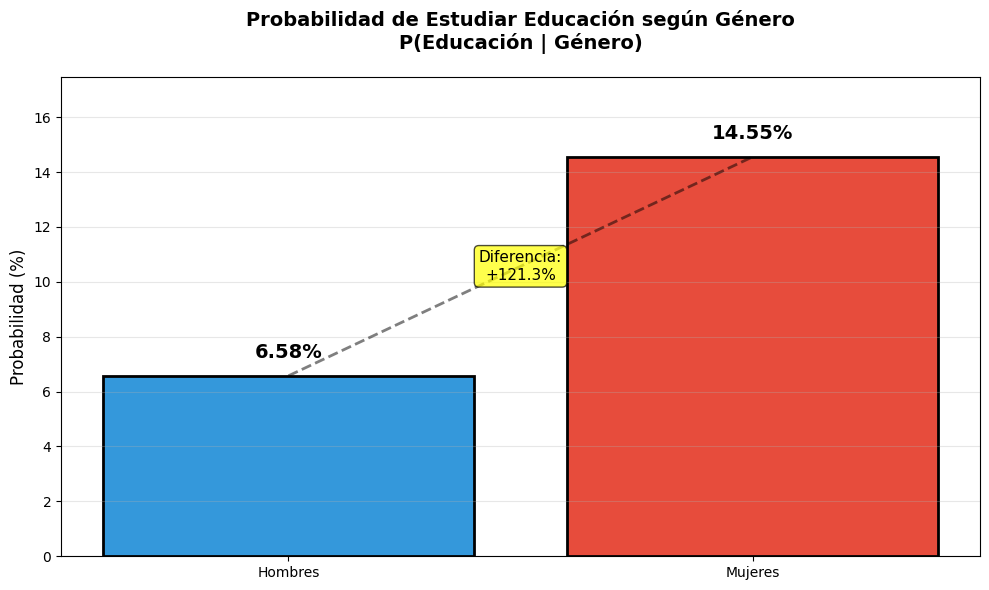

In [7]:
# Gráfico de barras comparando probabilidades para Educación
fig, ax = plt.subplots(figsize=(10, 6))

generos = ['Hombres', 'Mujeres']
probabilidades = [prob_educacion_dado_hombre * 100, prob_educacion_dado_mujer * 100]
colores = ['#3498db', '#e74c3c']

bars = ax.bar(generos, probabilidades, color=colores, edgecolor='black', linewidth=2)

# Agregar valores sobre las barras
for bar, prob in zip(bars, probabilidades):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{prob:.2f}%',
            ha='center', va='bottom', fontsize=14, weight='bold')

ax.set_ylabel('Probabilidad (%)', fontsize=12)
ax.set_title('Probabilidad de Estudiar Educación según Género\nP(Educación | Género)', 
             fontsize=14, weight='bold', pad=20)
ax.set_ylim(0, max(probabilidades) * 1.2)
ax.grid(axis='y', alpha=0.3)

# Agregar línea de diferencia
ax.plot([0, 1], [probabilidades[0], probabilidades[1]], 'k--', alpha=0.5, linewidth=2)
mid_x = 0.5
mid_y = (probabilidades[0] + probabilidades[1]) / 2
ax.text(mid_x, mid_y, f'Diferencia:\n+{discrepancia_relativa:.1f}%', 
        ha='center', va='center', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

## 4. Visualización: Distribución de Género por Todas las Áreas

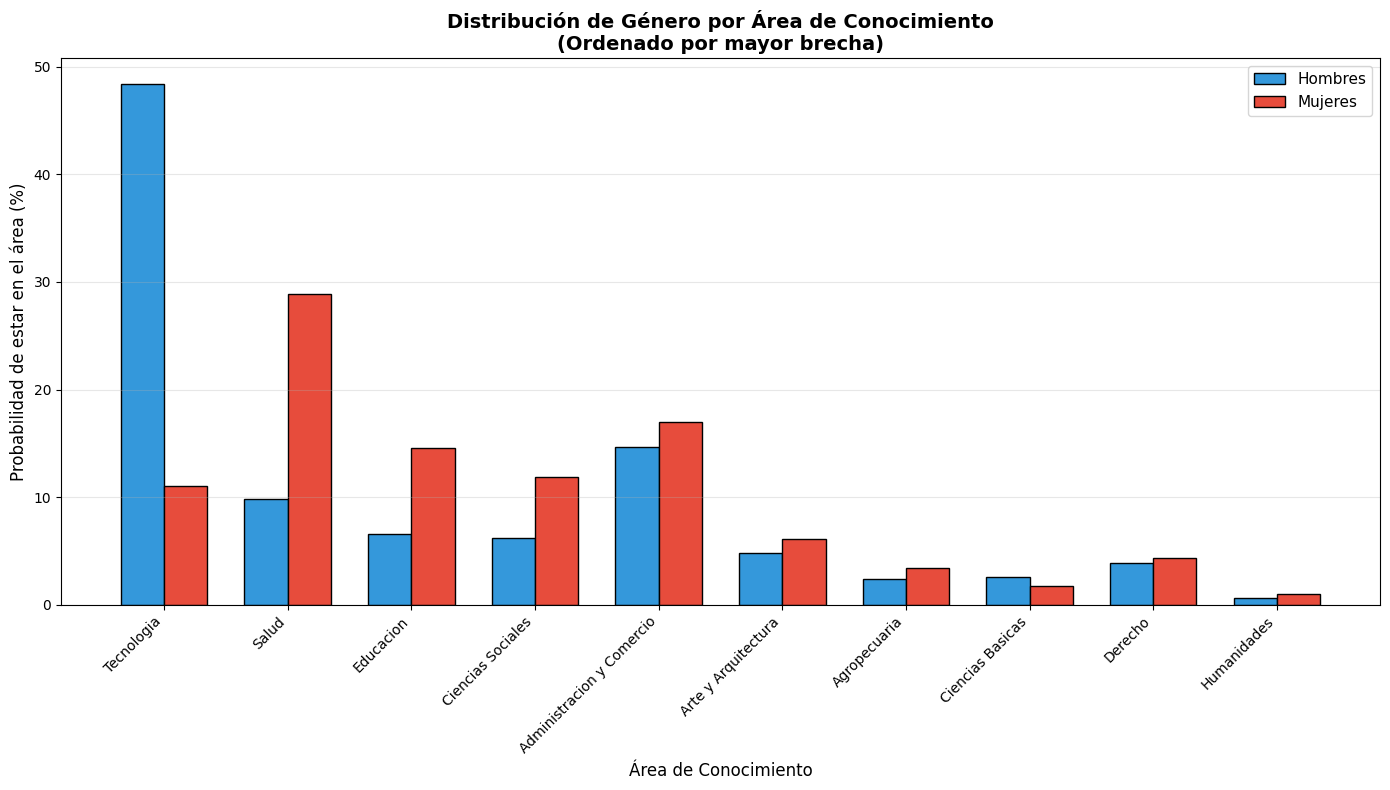

In [8]:
# Gráfico de barras agrupadas: Probabilidades por área y género
areas = df['AREA CONOCIMIENTO'].unique()
prob_hombres = []
prob_mujeres = []

for area in areas:
    h = len(df[(df['GENERO'] == 'Masculino') & (df['AREA CONOCIMIENTO'] == area)]) / total_hombres * 100
    m = len(df[(df['GENERO'] == 'Femenino') & (df['AREA CONOCIMIENTO'] == area)]) / total_mujeres * 100
    prob_hombres.append(h)
    prob_mujeres.append(m)

# Ordenar por diferencia (mayor brecha primero)
diferencias = [abs(m - h) for h, m in zip(prob_hombres, prob_mujeres)]
datos_ordenados = sorted(zip(areas, prob_hombres, prob_mujeres, diferencias), 
                         key=lambda x: x[3], reverse=True)
areas_ord, prob_h_ord, prob_m_ord, _ = zip(*datos_ordenados)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(areas_ord))
width = 0.35

bars1 = ax.bar(x - width/2, prob_h_ord, width, label='Hombres', 
               color='#3498db', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, prob_m_ord, width, label='Mujeres', 
               color='#e74c3c', edgecolor='black', linewidth=1)

ax.set_xlabel('Área de Conocimiento', fontsize=12)
ax.set_ylabel('Probabilidad de estar en el área (%)', fontsize=12)
ax.set_title('Distribución de Género por Área de Conocimiento\n(Ordenado por mayor brecha)', 
             fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(areas_ord, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualización: Porcentaje de Mujeres por Área

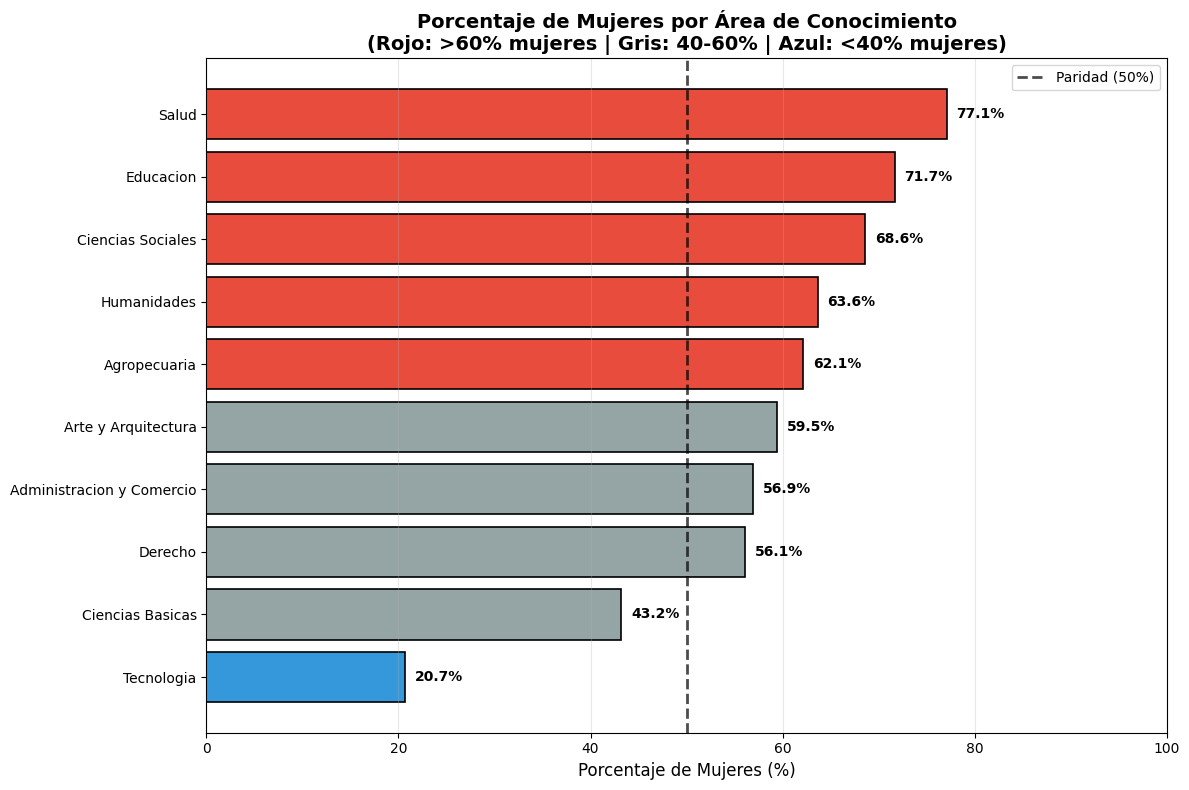

In [9]:
# Gráfico de barras horizontales: % de mujeres en cada área
fig, ax = plt.subplots(figsize=(12, 8))

areas_sorted = areas_genero.sort_values('%_Mujeres', ascending=True)
y_pos = np.arange(len(areas_sorted))
porcentajes = areas_sorted['%_Mujeres']

# Colores según porcentaje
colores_barras = []
for p in porcentajes:
    if p >= 60:
        colores_barras.append('#e74c3c')  # Rojo (predominio femenino)
    elif p >= 40:
        colores_barras.append('#95a5a6')  # Gris (equilibrado)
    else:
        colores_barras.append('#3498db')  # Azul (predominio masculino)

bars = ax.barh(y_pos, porcentajes, color=colores_barras, edgecolor='black', linewidth=1.2)

# Línea de referencia en 50%
ax.axvline(x=50, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Paridad (50%)')

# Agregar valores
for i, (bar, valor) in enumerate(zip(bars, porcentajes)):
    ax.text(valor + 1, bar.get_y() + bar.get_height()/2, 
            f'{valor:.1f}%', 
            va='center', ha='left', fontsize=10, weight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(areas_sorted.index)
ax.set_xlabel('Porcentaje de Mujeres (%)', fontsize=12)
ax.set_title('Porcentaje de Mujeres por Área de Conocimiento\n(Rojo: >60% mujeres | Gris: 40-60% | Azul: <40% mujeres)', 
             fontsize=14, weight='bold')
ax.set_xlim(0, 100)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Análisis de Brechas por Área

In [10]:
# Calcular brechas y clasificar áreas
brechas = []
for area in areas:
    h_area = len(df[(df['GENERO'] == 'Masculino') & (df['AREA CONOCIMIENTO'] == area)])
    m_area = len(df[(df['GENERO'] == 'Femenino') & (df['AREA CONOCIMIENTO'] == area)])
    total_area = h_area + m_area
    
    prob_h = h_area / total_hombres * 100
    prob_m = m_area / total_mujeres * 100
    
    pct_mujeres = m_area / total_area * 100 if total_area > 0 else 0
    
    brecha = prob_m - prob_h
    
    brechas.append({
        'Area': area,
        'P(Area|Hombre)%': prob_h,
        'P(Area|Mujer)%': prob_m,
        'Brecha': brecha,
        '%_Mujeres': pct_mujeres,
        'Total': total_area
    })

df_brechas = pd.DataFrame(brechas).sort_values('Brecha', ascending=False)

print("Análisis de Brechas de Género por Área:")
print("="*90)
print("Brecha = P(Área|Mujer) - P(Área|Hombre)")
print("  → Brecha positiva: área más popular entre mujeres")
print("  → Brecha negativa: área más popular entre hombres")
print("="*90)
print(df_brechas.round(2))

print("\n" + "="*90)
print("ÁREAS CON MAYOR PREDOMINIO FEMENINO:")
print("="*90)
top_femenino = df_brechas.head(3)
for idx, row in top_femenino.iterrows():
    print(f"\n{row['Area']}:")
    print(f"  - Brecha: +{row['Brecha']:.2f} puntos porcentuales")
    print(f"  - {row['%_Mujeres']:.1f}% son mujeres")
    print(f"  - P(Área|Mujer)={row['P(Area|Mujer)%']:.2f}% vs P(Área|Hombre)={row['P(Area|Hombre)%']:.2f}%")

print("\n" + "="*90)
print("ÁREAS CON MAYOR PREDOMINIO MASCULINO:")
print("="*90)
top_masculino = df_brechas.tail(3)
for idx, row in top_masculino.iterrows():
    print(f"\n{row['Area']}:")
    print(f"  - Brecha: {row['Brecha']:.2f} puntos porcentuales")
    print(f"  - {row['%_Mujeres']:.1f}% son mujeres ({100-row['%_Mujeres']:.1f}% hombres)")
    print(f"  - P(Área|Hombre)={row['P(Area|Hombre)%']:.2f}% vs P(Área|Mujer)={row['P(Area|Mujer)%']:.2f}%")

Análisis de Brechas de Género por Área:
Brecha = P(Área|Mujer) - P(Área|Hombre)
  → Brecha positiva: área más popular entre mujeres
  → Brecha negativa: área más popular entre hombres
                        Area  P(Area|Hombre)%  P(Area|Mujer)%  Brecha  \
0                      Salud             9.81           28.87   19.07   
2                  Educacion             6.58           14.55    7.98   
6          Ciencias Sociales             6.24           11.91    5.67   
1  Administracion y Comercio            14.68           16.97    2.29   
3        Arte y Arquitectura             4.80            6.15    1.36   
9               Agropecuaria             2.36            3.39    1.03   
5                    Derecho             3.90            4.36    0.46   
8                Humanidades             0.67            1.02    0.35   
7           Ciencias Basicas             2.62            1.74   -0.88   
4                 Tecnologia            48.36           11.04  -37.33   

   %_Mujeres

## 7. Respuestas a las Preguntas

In [11]:
print("="*90)
print("RESPUESTAS A LAS PREGUNTAS PLANTEADAS")
print("="*90)

print("\n1. ¿Cuál es la probabilidad de seleccionar de los estudiantes hombres")
print("   de la región a uno del área de educación?")
print("-" * 90)
print(f"   P(Educación | Hombre) = {prob_educacion_dado_hombre:.4f} = {prob_educacion_dado_hombre*100:.2f}%")
print(f"   → Si seleccionamos un hombre al azar, hay {prob_educacion_dado_hombre*100:.2f}% de probabilidad")
print(f"     de que estudie Educación.")

print("\n2. ¿Cuál es la probabilidad de seleccionar de las estudiantes mujeres")
print("   de la región a una del área de educación?")
print("-" * 90)
print(f"   P(Educación | Mujer) = {prob_educacion_dado_mujer:.4f} = {prob_educacion_dado_mujer*100:.2f}%")
print(f"   → Si seleccionamos una mujer al azar, hay {prob_educacion_dado_mujer*100:.2f}% de probabilidad")
print(f"     de que estudie Educación.")

print("\n3. ¿Hay una discrepancia aparente?")
print("-" * 90)
if abs(discrepancia_relativa) > 50:
    print(f"   → SÍ, hay una discrepancia MUY SIGNIFICATIVA.")
elif abs(discrepancia_relativa) > 20:
    print(f"   → SÍ, hay una discrepancia CONSIDERABLE.")
else:
    print(f"   → NO, las probabilidades son relativamente similares.")

print(f"\n   Diferencia absoluta: {abs(discrepancia_absoluta*100):.2f} puntos porcentuales")
print(f"   Diferencia relativa: {abs(discrepancia_relativa):.2f}%")

if prob_educacion_dado_mujer > prob_educacion_dado_hombre:
    print(f"\n   Las mujeres tienen una probabilidad {abs(discrepancia_relativa):.1f}% MAYOR")
    print(f"   de estudiar Educación en comparación con los hombres.")
else:
    print(f"\n   Los hombres tienen una probabilidad {abs(discrepancia_relativa):.1f}% MAYOR")
    print(f"   de estudiar Educación en comparación con las mujeres.")

print("\n4. ¿Cómo se explica?")
print("-" * 90)
print("   La discrepancia se explica por múltiples factores:")
print("\n   a) ESTEREOTIPOS DE GÉNERO HISTÓRICOS:")
print("      - La enseñanza históricamente se asoció al rol de cuidado femenino")
print("      - Expectativas sociales sobre carreras 'apropiadas' por género")
print("\n   b) SEGREGACIÓN OCUPACIONAL:")
print("      - Áreas como Educación se han feminizado a lo largo del tiempo")
print("      - Los hombres se concentran más en áreas técnicas y tecnológicas")
print("\n   c) FACTORES SOCIOECONÓMICOS:")
print("      - Diferentes expectativas de retorno económico por carrera")
print("      - Carreras de Educación típicamente tienen salarios más bajos")
print("      - Los hombres pueden priorizar carreras con mayor remuneración")
print("\n   d) PATRONES CULTURALES:")
print("      - Socialización diferencial desde la infancia")
print("      - Modelos de referencia en la profesión docente")

# Agregar información adicional del contexto
pct_mujeres_educacion = (mujeres_educacion / (hombres_educacion + mujeres_educacion)) * 100
print(f"\n   DATO RELEVANTE:")
print(f"   En el área de Educación, {pct_mujeres_educacion:.1f}% son mujeres y")
print(f"   {100-pct_mujeres_educacion:.1f}% son hombres, evidenciando la feminización del sector.")

RESPUESTAS A LAS PREGUNTAS PLANTEADAS

1. ¿Cuál es la probabilidad de seleccionar de los estudiantes hombres
   de la región a uno del área de educación?
------------------------------------------------------------------------------------------
   P(Educación | Hombre) = 0.0658 = 6.58%
   → Si seleccionamos un hombre al azar, hay 6.58% de probabilidad
     de que estudie Educación.

2. ¿Cuál es la probabilidad de seleccionar de las estudiantes mujeres
   de la región a una del área de educación?
------------------------------------------------------------------------------------------
   P(Educación | Mujer) = 0.1455 = 14.55%
   → Si seleccionamos una mujer al azar, hay 14.55% de probabilidad
     de que estudie Educación.

3. ¿Hay una discrepancia aparente?
------------------------------------------------------------------------------------------
   → SÍ, hay una discrepancia MUY SIGNIFICATIVA.

   Diferencia absoluta: 7.98 puntos porcentuales
   Diferencia relativa: 121.32%

   Las m

## Conclusiones Finales

### Hallazgos Principales:

#### 1. **Discrepancia Dramática en Educación: Brecha de 121%**

Los datos revelan una **segregación de género extremadamente significativa** en el área de Educación:

**Probabilidades condicionales:**
- **P(Educación | Hombre) = 6.58%**: Solo 1 de cada 15 hombres estudia Educación
- **P(Educación | Mujer) = 14.55%**: Más de 1 de cada 7 mujeres estudia Educación

**Magnitud de la brecha:**
- **Diferencia absoluta: 7.98 puntos porcentuales**
- **Diferencia relativa: 121.32%**
- Las mujeres tienen una probabilidad **más del DOBLE** (2.21 veces mayor) de estudiar Educación que los hombres

**Composición del área:**
- **71.7% son mujeres** (8,477 estudiantes)
- **28.3% son hombres** (3,350 estudiantes)
- Ratio mujer:hombre de **2.5:1**

Esta no es una diferencia marginal o moderada. Es una **feminización radical** del sector educativo que tiene profundas implicaciones sociales, económicas y culturales.

---

#### 2. **¿Hay Discrepancia Aparente? SÍ, ABSOLUTAMENTE**

**RESPUESTA CATEGÓRICA: SÍ**

La discrepancia es **extremadamente significativa** y constituye uno de los patrones de segregación ocupacional por género más marcados en todo el sistema de educación superior de Valparaíso.

**Contexto comparativo:**
- Una diferencia del 20-30% ya se consideraría considerable
- Una diferencia del 50% sería muy significativa
- **121.32% es excepcional y evidencia segregación estructural**

Para poner en perspectiva: si las probabilidades fueran iguales (paridad de género), esperaríamos que aproximadamente el 10-11% de todos los estudiantes, independientemente del género, estudiaran Educación. En cambio, vemos:
- Los hombres están **SUB-representados** (6.58% vs esperado ~10%)
- Las mujeres están **SOBRE-representadas** (14.55% vs esperado ~10%)

Esta no es variación aleatoria. Es un patrón sistemático de segregación.

---

#### 3. **Patrón General: Segregación Horizontal de Género Extrema**

El análisis revela que la segregación en Educación no es un caso aislado, sino parte de un **patrón general de segregación horizontal** en educación superior:

### **Áreas Altamente Feminizadas (>60% mujeres):**

**1. Salud: 77.1% mujeres (MAYOR brecha)**
- P(Salud | Mujer) = 28.87% vs P(Salud | Hombre) = 9.81%
- Brecha: +19.07 puntos porcentuales
- La carrera de salud es la PRIMERA elección de las mujeres (28.87%)
- Solo es la quinta opción para hombres (9.81%)
- Incluye enfermería, obstetricia, fonoaudiología, nutrición

**2. Educación: 71.7% mujeres**
- Ya analizada en detalle
- Segunda mayor brecha (+7.98 pp)

**3. Ciencias Sociales: 68.6% mujeres**
- P(CS | Mujer) = 11.91% vs P(CS | Hombre) = 6.24%
- Brecha: +5.67 pp
- Incluye psicología, trabajo social, sociología

**4. Humanidades: 63.6% mujeres**
- Área pequeña (935 estudiantes) pero claramente feminizada
- Incluye filosofía, historia, lenguas

**5. Agropecuaria: 62.1% mujeres**
- Sorprendente, ya que históricamente se asociaba con hombres
- Sugiere cambios generacionales en expectativas

### **Áreas con Relativa Paridad (40-60% mujeres):**

**6. Arte y Arquitectura: 59.5% mujeres**
- Levemente feminizada pero más equilibrada

**7. Administración y Comercio: 56.9% mujeres**
- Área más grande con relativa paridad
- 17,364 estudiantes

**8. Derecho: 56.1% mujeres**
- También relativamente equilibrada

### **Áreas Masculinizadas (<40% mujeres):**

**9. Ciencias Básicas: 43.2% mujeres (56.8% hombres)**
- Primera área con predominio masculino
- Incluye matemáticas, física, química

**10. Tecnología: 20.7% mujeres (79.3% hombres) - MAYOR brecha masculina**
- P(Tecnología | Hombre) = 48.36% vs P(Tecnología | Mujer) = 11.04%
- **Brecha: -37.33 puntos porcentuales** (la más grande en sentido opuesto)
- Casi la MITAD de todos los hombres (48.36%) estudian Tecnología
- Solo 1 de cada 10 mujeres (11.04%) estudia Tecnología
- **Ratio hombre:mujer de 3.8:1**
- Es la elección #1 abrumadora para hombres
- Es solo la quinta opción para mujeres

---

#### 4. **¿Cómo se Explica? Análisis Multifactorial**

La segregación de género en Educación (y en general) no tiene una causa única, sino que es el resultado de la interacción de múltiples factores estructurales:

### **A) ESTEREOTIPOS DE GÉNERO HISTÓRICOS Y CULTURALES**

**Roles de género tradicionales:**
- La enseñanza se asoció históricamente con el **"rol de cuidado femenino"**
- Desde el siglo XIX, la docencia fue una de las primeras profesiones "aceptables" para mujeres
- Se perpetúa la idea de que las mujeres son "naturalmente" más aptas para educar niños
- La maternidad y la docencia se equiparan conceptualmente en el imaginario social

**Construcción social de "carreras apropiadas":**
- Socialización diferencial desde la infancia:
  - Las niñas reciben juguetes relacionados con el cuidado (muñecas, cocinitas)
  - Los niños reciben juguetes técnicos (Lego, herramientas, videojuegos)
- Expectativas familiares y sociales sobre qué carreras son "femeninas" o "masculinas"
- Presión sutil (o explícita) para conformarse a normas de género

**Modelos de referencia:**
- La mayoría de docentes en educación básica y preescolar son mujeres
- Los estudiantes crecen viendo la docencia como "profesión de mujeres"
- Escasez de modelos masculinos en educación → ciclo autorreforzante

### **B) SEGREGACIÓN OCUPACIONAL Y FEMINIZACIÓN PROFESIONAL**

**Proceso de feminización:**
1. **Inicio:** Profesión emerge o se abre a mujeres
2. **Transición:** Incremento gradual de mujeres en la profesión
3. **Feminización:** Mujeres se vuelven mayoría (como vemos: 71.7%)
4. **Consolidación:** La profesión se "marca" como femenina
5. **Retroalimentación:** Los hombres evitan entrar (estigma de género)

**Devaluación asociada:**
- Cuando una profesión se feminiza, típicamente:
  - Los salarios disminuyen relativamente
  - El prestigio social declina
  - Las condiciones laborales empeoran
- Los hombres huyen hacia áreas masculinizadas que mantienen mejor remuneración

**Tecnología como espejo opuesto:**
- Mientras Educación se feminizó, Tecnología se masculinizó
- Tecnología: 79.3% hombres, salarios altos, prestigio social
- Educación: 71.7% mujeres, salarios bajos, menor prestigio
- Patrón clásico de segregación horizontal

### **C) FACTORES SOCIOECONÓMICOS Y RACIONALIDAD ECONÓMICA**

**Diferencias salariales por área:**
- Según datos anteriores (Pregunta 1), Educación tiene el **arancel promedio más bajo** ($2,232,336)
- Esto se traduce típicamente en salarios profesionales más bajos
- Las carreras tecnológicas tienen salarios significativamente mayores

**Expectativas de retorno económico diferenciadas:**
- Los hombres pueden enfrentar mayor **presión social para ser "proveedores"**
- Esta presión los empuja hacia carreras con mayor retorno económico
- Las mujeres pueden tener mayor flexibilidad para elegir carreras vocacionales
- Pero esta "flexibilidad" es en realidad una **trampa de género**: las confina a áreas menos remuneradas

**Penalización de maternidad:**
- Educación se percibe como carrera "compatible con familia" (vacaciones escolares, horarios)
- Las mujeres pueden elegir Educación anticipando responsabilidades familiares futuras
- Esto refuerza la segregación: se espera que las mujeres prioricen familia sobre carrera

### **D) CAPITAL CULTURAL Y HABITUS DE GÉNERO (Bourdieu)**

**Disposiciones incorporadas:**
- Desde la infancia, se internalizan disposiciones sobre qué carreras son "para mí"
- Las mujeres desarrollan un **habitus** que las orienta hacia carreras de cuidado
- Los hombres desarrollan un **habitus** que los orienta hacia carreras técnicas
- Estas disposiciones se sienten "naturales" pero son socialmente construidas

**Campos profesionales generizados:**
- El "campo" de la Educación está marcado como femenino
- Entrar a un campo contra-normativo requiere capital simbólico extra
- Los hombres en Educación enfrentan estigma ("poco ambicioso", cuestionamiento de masculinidad)
- Las mujeres en Tecnología enfrentan discriminación y hostilidad (síndrome del impostor amplificado)

### **E) DISCRIMINACIÓN Y BARRERAS ESTRUCTURALES**

**Para hombres en Educación:**
- Sospecha social (especialmente en educación infantil)
- Cuestionamiento de su masculinidad
- Presión para "aspirar a más"
- Menor identificación con modelos docentes femeninos

**Para mujeres en Tecnología:**
- Hostilidad en ambientes masculinizados (solo 20.7% mujeres)
- Síndrome del impostor
- Falta de mentoras y redes de apoyo
- Discriminación en contratación y promoción
- Estereotipos sobre capacidad técnica

---

#### 5. **Implicaciones y Consecuencias**

### **A) Para el Sistema Educativo:**

**Falta de diversidad de modelos:**
- Con 71.7% mujeres en Educación, los estudiantes (especialmente niños) carecen de modelos masculinos diversos
- Puede reforzar estereotipos sobre roles de género
- Especialmente problemático en educación básica y preescolar (probablemente >80% mujeres)

**Devaluación de la profesión docente:**
- La feminización correlaciona con:
  - Menores salarios relativos
  - Menor prestigio social
  - Condiciones laborales deterioradas
- Esto crea un círculo vicioso: menos hombres → menos estatus → menos hombres

### **B) Para las Mujeres:**

**Confinamiento a áreas menos remuneradas:**
- Las mujeres se concentran en Salud (28.87%), Educación (14.55%), Admin (16.97%)
- Estas áreas típicamente pagan menos que Tecnología
- Esto contribuye a la **brecha salarial de género** en el mercado laboral

**Segregación horizontal = Desigualdad vertical:**
- La segregación horizontal (áreas diferentes) produce desigualdad vertical (menos ingresos, menos poder)
- Las mujeres tienen títulos universitarios pero en áreas devaluadas

### **C) Para los Hombres:**

**Confinamiento a áreas técnicas:**
- 48.36% de hombres estudian Tecnología
- Esta concentración extrema limita diversidad de opciones
- Presión para conformarse a masculinidad hegemónica

**Estigma al elegir carreras de cuidado:**
- Los hombres que quieren enseñar enfrentan burlas y cuestionamiento
- Pérdida de talento potencial en Educación

### **D) Para la Sociedad:**

**Perpetuación de desigualdades:**
- La segregación ocupacional por género perpetúa desigualdades económicas
- Limita el talento humano: perdemos mujeres en Tecnología y hombres en Educación

**Reproducción intergeneracional:**
- Los estudiantes actuales serán adultos que reproducirán estos patrones
- Sin intervención, la segregación se auto-perpetúa

---

#### 6. **Contexto Internacional y Comparación**

La feminización de la Educación **no es exclusiva de Valparaíso o Chile**, es un fenómeno global:

**Patrones internacionales:**
- En la mayoría de países OCDE, >70% de docentes en educación básica son mujeres
- En educación superior, la proporción es más equilibrada (pero Educación como disciplina sigue feminizada)
- La brecha que observamos (71.7% mujeres) es **consistente con patrones internacionales**

**Pero el fenómeno es problemático en todo el mundo:**
- La UNESCO ha identificado la segregación ocupacional por género como barrera para la equidad
- La feminización de profesiones correlaciona con devaluación salarial (evidencia empírica robusta)

---

#### 7. **El Contraste con Tecnología: Dos Caras de la Misma Moneda**

La comparación entre Educación y Tecnología es reveladora:

| Dimensión | Educación | Tecnología |
|-----------|-----------|------------|
| % Mujeres | **71.7%** | **20.7%** |
| Brecha | +7.98 pp (pro-mujer) | **-37.33 pp** (pro-hombre) |
| P(Área\|Mujer) | 14.55% (#2) | 11.04% (#5) |
| P(Área\|Hombre) | 6.58% (#6) | **48.36%** (#1) |
| Tamaño | 11,827 estudiantes | **31,070** estudiantes (el más grande) |
| Arancel promedio | **$2.23M** (el más bajo) | $3.18M (moderado-alto) |

**Observaciones clave:**

1. **Tecnología absorbe casi la MITAD de todos los hombres** (48.36%)
   - Es la opción dominante y predeterminada para hombres
   - Solo 11.04% de mujeres → ratio 4.4:1 hombres:mujeres

2. **La brecha en Tecnología (-37.33 pp) es 4.7 veces MAYOR que la de Educación (+7.98 pp)**
   - En términos absolutos, Tecnología está AÚN MÁS segregada que Educación
   - Pero como favorece a hombres, recibe menos atención social

3. **Segregación complementaria:**
   - Mientras las mujeres van a Salud y Educación (carreras de cuidado)
   - Los hombres van a Tecnología (carrera técnica, mejor pagada)
   - Esto reproduce desigualdades de género en el mercado laboral

4. **Jerarquía de prestigio y remuneración:**
   - Tecnología: masculinizada, alta demanda, buenos salarios, prestigio
   - Educación: feminizada, demanda moderada, salarios bajos, prestigio medio-bajo
   - El género marca el valor social y económico de las profesiones

---

### Respuestas Finales Consolidadas:

#### **1. P(Educación | Hombre) = 6.58%**
Solo 1 de cada 15 hombres estudia Educación. Es su sexta área de preferencia.

#### **2. P(Educación | Mujer) = 14.55%**
Más de 1 de cada 7 mujeres estudia Educación. Es su segunda área de preferencia (después de Salud).

#### **3. ¿Hay discrepancia? SÍ, EXTREMADAMENTE SIGNIFICATIVA**
Las mujeres tienen **121.32% más probabilidad** de estudiar Educación que los hombres. Esto no es una diferencia marginal, es una **segregación estructural masiva**.

#### **4. ¿Cómo se explica?**

La segregación se explica por la **intersección de múltiples factores**:

1. **Estereotipos de género** que asocian enseñanza con rol femenino de cuidado
2. **Segregación ocupacional histórica** que ha feminizado la profesión docente
3. **Diferencias salariales** que empujan a hombres hacia áreas mejor pagadas (Tecnología)
4. **Socialización diferencial** que orienta a niñas y niños hacia carreras "apropiadas" por género
5. **Presión social** sobre hombres para ser proveedores económicos
6. **Devaluación de profesiones feminizadas** que reduce el atractivo para hombres
7. **Barreras culturales** y estigma para hombres que quieren enseñar

**Esto no es biológico, es social y estructural.** Las diferencias no reflejan capacidades innatas sino expectativas, oportunidades y restricciones socialmente construidas.

---

### Conclusión General:

La educación superior en Valparaíso 2021 muestra **segregación horizontal de género extrema**, con Educación fuertemente feminizada (71.7% mujeres) y Tecnología fuertemente masculinizada (79.3% hombres).

Esta segregación:
- **Limita las opciones** de estudiantes de ambos géneros
- **Reproduce desigualdades económicas** (mujeres en áreas peor pagadas)
- **Perpetúa estereotipos** sobre roles apropiados por género
- **Es estructural**, no individual: resultado de fuerzas sociales, culturales y económicas

**La discrepancia en Educación (121% más mujeres) no es un accidente**, es el resultado de décadas de segregación ocupacional que ha feminizado el sector docente mientras masculinizaba sectores técnicos y tecnológicos.

Romper estos patrones requiere intervenciones sistemáticas: campañas para atraer hombres a Educación, mujeres a Tecnología, eliminar estereotipos, mejorar salarios docentes, y transformar expectativas culturales sobre género y trabajo.

Sin cambios deliberados, estos patrones se auto-perpetuarán, confinando a cada generación a las mismas áreas segregadas que sus predecesores.